# Birdsong steganography
## Hiding messages in birdsongs
#### [V. Hunter Adams](https://vanhunteradams.com)

In [1]:
import numpy
import numpy as np
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt
from IPython.display import Audio
from IPython.display import Image
from scipy import signal
from scipy.fft import fftshift
from scipy.io import wavfile
plt.rcParams['figure.figsize'] = [12, 4]
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

> - [Introduction](#Introduction)
> - [House Finch](#House-Finch)
> > - [Syllables to symbols](#Syllables-to-symbols)
> > - [Spline-fitting the frequency sweeps](#Spline-fitting-the-frequency-sweeps)
> > - [Generating tones from frequencies](#Generating-tones-from-frequencies)
> > - [Composing songs](#Composing-songs)
> > > - [The real song](#The-real-song)
> > > - [Hello world!](#Hello-world!)
> > > - [Birds aren't real](#Birds-aren't-real)

## Introduction

This document contains a collection of thoughts about (and demonstrations of) hiding information in birdsongs ("birdsong steganography?"). As yet, these thoughts and demonstrations are largely of the "proof of concept" variety. That is, the described steganographic techniques are easy to intuit/understand and, as a consequence, probably somewhat easy to detect. Even so, I think they're a lot of fun! They're a neat example of [natural memory](https://vanhunteradams.com/Talks/Natural_Computing.pdf).

I'm still thinking a lot about this stuff. If more/sneakier techniques occur to me, I'll document them here. 

Some of my other webpages provide some potentially useful background:
> - [Direct Digital Synthesis](https://vanhunteradams.com/DDS/DDS.html): This is the algorithm that's used on this webpage to generate songbird songs.
> - [Synthesizing birdsongs with DDS](https://vanhunteradams.com/Pico/Birds/Birdsong_synthesis.html): Describes how to use DDS in order to generate birdsongs.


***

## House Finch

The [song](https://macaulaylibrary.org/asset/22938) of a [house finch](https://www.allaboutbirds.org/guide/Northern_Cardinal) lasts about three seconds, and is composed of a jumbled collection of warbling syllables. You can click the link below to listen to one singing.

<iframe src="https://macaulaylibrary.org/asset/22938/embed" height="510" width="640" frameborder="0" allowfullscreen></iframe>

***

### Syllables to symbols

These songs are well-suited to a very straightforward method of steganography. There's a sufficiently large alphabet of syllables for us to associate each with a hexadecimal digit. Then we can compose synthetic songs with a syllable-order that communicates a particular message. For instance, we can send "Hello world!" by considering the pair of syllables which map to the pair of hexadecimal values that compose the ASCII representation of each of the characters in this messages. By generating a song composed of these syllables in this order, we can send a message that is easily decodable via its spectrogram, but that still sounds an awful lot like a finch! In fact, as we'll see, it even tricks Merlin!

The image below is from the recording embedded above. I've annotated the 16 maximally distinguishable symbols in this particular song with an associated hex value.

<img align="center" width="1000" height="1000" src="symbols.png">

### Spline-fitting the frequency sweeps

If we were synthesizing these songs on a memory-constrained microcontroller (like in [lab 1 for ECE 4760](https://vanhunteradams.com/Pico/Birds/Birdsong.html)) we would fit each of the frequency sweeps that compose each syllable to functions of time, and we would compute those functions on the fly. Since we're on a PC and we've got memory to spend, we may as well spend it. So we instead use a cubic spline to approximate these curves based on a few sample points (as eyeballed from the above image) and we'll store each song in its own separate array.

You can click the "show code" button at the top of this page to see how this is done. The process for each symbol is quite repetetive. I've included the spline fit for the syllable associated with 0xF as an example.

In [2]:
sixteenth_syllable = numpy.array([
                            [0.0*3674, 2800],
                            [0.25*3674, 2300],
                            [0.5*3674, 3000],
                            [0.8*3674, 2000],
                            [0.9*3674, 2500],
                            [1.0*3674, 2500]
])

fifteenth_syllable = numpy.array([
                            [0.0*3674, 2000],
                            [0.25*3674, 3000],
                            [0.33*3674, 2900],
                            [0.5*3674, 3500],
                            [0.75*3674, 2100],
                            [0.8*3674, 2100],
                            [0.9*3674, 2100],
                            [1.0*3674, 2100]
])

fourteenth_syllable = numpy.array([
                            [0.0*3674, 2000],
                            [0.1*3674, 4000],
                            [0.15*3674, 3500],
                            [0.2*3674, 3000],
                            [0.5*3674, 2800],
                            [0.9*3674, 2700],
                            [1.0*3674, 2000.]
])

thirteenth_syllable = numpy.array([
                            [0.0*3674, 3900],
                            [0.1*3674, 3900],
                            [0.21*3674, 3900],
                            [0.23*3674, 3000],
                            [0.25*3674, 2500],
                            [0.28*3674, 3000],
                            [0.33*3674, 4100],
                            [0.4*3674, 4200],
                            [0.55*3674, 4300],
                            [0.6*3674, 3800],
                            [0.65*3674, 4100],
                            [0.75*3674, 4200],
                            [1.0*3674, 4300]
])

twelfth_syllable = numpy.array([
                            [0.0*3674, 4300],
                            [0.1*3674, 4200],
                            [0.2*3674, 3700],
                            [0.21*3674, 4200],
                            [0.5*3674, 3800],
                            [0.6*3674, 3500],
                            [0.7*3674, 3400],
                            [0.8*3674, 3000],
                            [1.0*3674, 2100]
])

gap_syllable = numpy.array([
                            [0.0*3674, 2000.],
                            [0.1*3674, 2200.],
                            [0.2*3674, 2000.],
                            [0.3*3674, 1900.],
                            [0.45*3674, 1800.],
                            [0.55*3674, 3500.],
                            [0.75*3674, 4300.],
                            [0.95*3674, 4100.],
                            [1.00*3674, 4000.]
])

eleventh_syllable = numpy.array([
                            [0.0*3674, 2100.],
                            [0.25*3674, 3000.],
                            [0.33*3674, 2800.],
                            [0.5*3674, 2500.],
                            [0.75*3674, 3500.],
                            [1.00*3674, 4000.]
])

tenth_syllable = numpy.array([
                            [0.0*3674, 2100.],
                            [0.1*3674, 2200.],
                            [0.2*3674, 2100.],
                            [0.25*3674, 2000.],
                            [0.30*3674, 1900.],
                            [0.33*3674, 1800.],
                            [0.5*3674, 3300.],
                            [0.6*3674, 2200.],
                            [0.65*3674, 2200.],
                            [0.8*3674, 2200.],
                            [0.9*3674, 3200.],
                            [0.95*3674, 3200.],
                            [1.0*3674, 3200.]
])

ninth_syllable = numpy.array([
                            [0.0*3674, 3000.],
                            [0.125*3674, 3000.],
                            [0.25*3674, 3000.],
                            [0.33*3674, 2300.],
                            [0.5*3674, 4000.],
                            [0.66*3674, 3300.],
                            [0.75*3674, 3300.],
                            [0.8*3674, 3300.],
                            [0.9*3674, 3300.],
                            [1.0*3674, 3300.]
])

eigth_syllable = np.array([
                            [0.0*3674, 2800.],
                            [0.25*3674, 4000.],
                            [0.5*3674, 2800.],
                            [0.52*3674, 2800.],
                            [0.6*3674, 2800.],
                            [0.7*3674, 2800.],
                            [0.8*3674, 2800.],
                            [0.98*3674, 2800.],
                            [1.0*3674, 2800.]
])

seventh_syllable = np.array([
                            [0.0*3674, 4000.],
                            [0.25*3674, 4000.],
                            [0.48*3674, 4000.],
                            [0.5*3674, 4000.],
                            [0.6*3674, 3600.],
                            [0.7*3674, 5000.],
                            [0.8*3674, 4500.],
                            [0.98*3674, 4000.],
                            [1.0*3674, 3900.]
])

sixth_syllable = np.array([
                            [0.0*3674, 4000.],
                            [0.25*3674, 4500.],
                            [0.48*3674, 4000.],
                            [0.5*3674, 3600.],
                            [0.52*3674, 4000.],
                            [0.75*3674, 4500.],
                            [0.95*3674, 4000.],
                            [0.98*3674, 3000.],
                            [1.0*3674, 2200.]
])

fifth_syllable = np.array([
                            [0.0*3674, 3900.],
                            [0.5*3674, 4100.],
                            [0.8*3674, 3900.],
                            [1.0*3674, 3000.]
])

fourth_syllable = np.array([
                            [0.0*3674, 4200.0],
                            [0.125*3675, 4500.0],
                            [0.33*3674, 4200.0],
                            [0.75*3674, 4500.],
                            [1.00*3674, 4000.0]
])

third_syllable = np.array([
                            [0.0*3674, 4300.],
                            [0.1*3674, 4500.],
                            [0.2*3674, 4300.],
                            [0.4*3674, 3300.],
                            [0.5*3674, 3300.],
                            [0.6*3674, 3300.],
                            [0.75*3674, 4500.],
                            [0.93*3674, 4100.],
                            [0.96*3674, 3500.],
                            [1.00*3674, 3000.]
])

second_syllable = np.array([
                            [0.0*3674, 4300.],
                            [0.1*3674, 4000.],
                            [0.33*3674, 5000.],
                            [0.5*3674, 4000.],
                            [0.8*3674, 2100.],
                            [1.0*3674, 2000.]
])

first_syllable = np.array([
                            [0.0*3674, 4000.0],
                            [0.2*3675, 3000.0],
                            [0.50*3674, 2000.0],
                            [0.90*3674, 4000],
                            [1.00*3674, 2000.0]
])

In [13]:
# A function that accepts a collection of points on the spectrogram,
# and computes a cubic spline that goes through those points. It will
# return a spline-fit array of a specified length.
#
# This length is set to 3674. At 44.1 kHz sample rate, this is about
# how long each of the syllables in the finch song lasts, as measured
# in audio samples.

def makeSpline(points, titletext, length=3674, makeplots=False):

    # Convert to the format splprep expects: shape (2, N)
    x, y = points[:, 0], points[:, 1]

    # Compute spline
    tck, u = splprep([x, y], s=0, k=2, per=False)

    # Generate a dense set of points along the smooth curve
    u_fine = np.linspace(0, 1, length)
    x_fine, y_fine = splev(u_fine, tck)
    
    # Plot?
    if makeplots:
        plt.figure(figsize=(10, 6))
        plt.plot(x, y, 'o', markersize=8, label='Original points', color='red')
        plt.plot(x_fine, y_fine, '-', linewidth=2.5, label='Smooth cubic spline', color='blue')

        plt.title(titletext)
        plt.xlabel('time (audio samples at 44.1kHz)')
        plt.ylabel('frequency (Hz)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
    
    ## DDS Synth
    Fs = 44100 #audio sample rate
    sintable = numpy.sin(numpy.linspace(0, 2*numpy.pi, 256))# sine table for DDS
    two32 = 2**32 #2^32
    
    audio_output = list(numpy.zeros(length))
    DDS_phase = 0 # current phase
    for i in range(length):
        frequency = y_fine[i]
        DDS_increment = frequency*two32/Fs # update DDS increment
        DDS_phase += DDS_increment # update DDS phase by increment
        DDS_phase = DDS_phase % (two32 - 1) # need to simulate overflow in python, not necessary in C
        audio_output[i] = sintable[int(DDS_phase/(2**24))] # can just shift in C
        
    # Amplitude modulate with a linear envelope to avoid clicks
    amplitudes = list(numpy.ones(length))
    amplitudes[0:500] = list(numpy.linspace(0,1,len(amplitudes[0:500])))
    amplitudes[-500:] = list(numpy.linspace(0,1,len(amplitudes[-500:]))[::-1])
    amplitudes = numpy.array(amplitudes)

    # Finish with the swoop
    audio_output = audio_output*amplitudes
    
    return audio_output

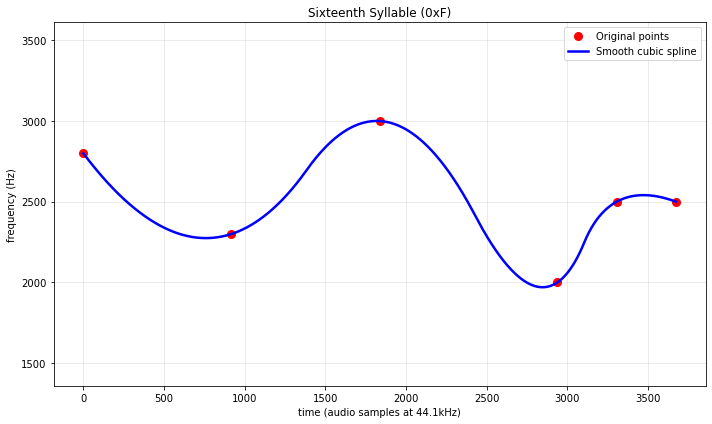

In [14]:
# Make an array for each syllable, named for the symbol it represents

hex_0 = makeSpline(first_syllable, 'First Syllable')
hex_1 = makeSpline(second_syllable, 'Second Syllable')
hex_2 = makeSpline(third_syllable, 'Third Syllable')
hex_3 = makeSpline(fourth_syllable, 'Fourth Syllable')
hex_4 = makeSpline(fifth_syllable, "Fifth Syllable")
hex_5 = makeSpline(sixth_syllable, 'Sixth Syllable')
hex_6 = makeSpline(seventh_syllable, 'Seventh Syllable')
hex_7 = makeSpline(eigth_syllable, 'Eighth Syllable')
hex_8 = makeSpline(ninth_syllable, 'Ninth Syllable')
hex_9 = makeSpline(tenth_syllable, 'Tenth Syllable')
hex_a = makeSpline(eleventh_syllable, 'Eleventh Syllable')
gap_syl = makeSpline(gap_syllable, 'Gap Syllable')
hex_b = makeSpline(twelfth_syllable, 'Twelfth Syllable')
hex_c = makeSpline(thirteenth_syllable, 'Thirteenth Syllable')
hex_d = makeSpline(fourteenth_syllable, 'Fourteenth Syllable')
hex_e = makeSpline(fifteenth_syllable, 'Fifteenth Syllable')
hex_f = makeSpline(sixteenth_syllable, 'Sixteenth Syllable (0xF)', makeplots=True)

### Generating tones from frequencies

The output of the spline fit for each curve is an array. Each element of the array contains the frequency that should be generated at the time associated with that particular array index. Time, in this context, is most conveniently measured in "audio samples." If we suppose that we are synthesizing audio at 44.1 kHz (standard audio rate), then we have 44,100 audio samples per second. Each of these arrays is of length 3674. That corresponds to 3674 audio samples, or about 83 ms. That's *approximately* how long each of the finch syllables last.

To generate sine waves of these desired frequency, we use Direct Digital Synthesis. Because I have a long explanation of this algorithm on [another webpage](https://vanhunteradams.com/DDS/DDS.html), I won't clutter this page with an explanation. Each of these syllables is amplitude-modulated on and off in order to avoid clicks and pops associated with rapid changes in amplitude.

I've included a plot of the waveform associated with the syllable 0xF below. The frequencies are too fast to see them modulating, but this modulation becomes apparent when we compute the spectrogram of the waveform. If you compare this spectrogram with the final syllable in the *real* birdsong spectrogram shown above, you'll see it's pretty close. Close enough to sound real!

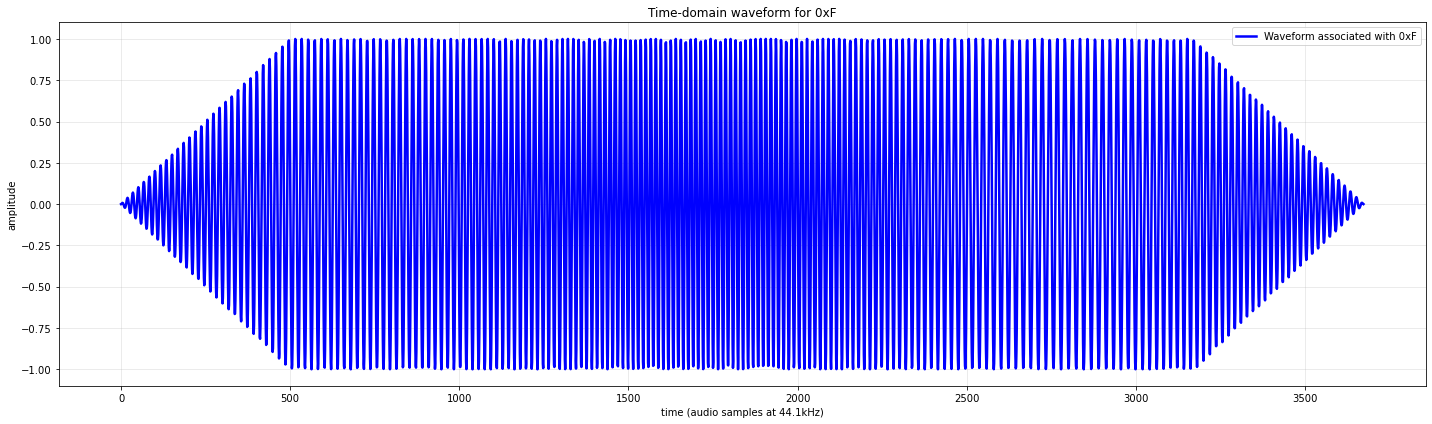

In [15]:
plt.figure(figsize=(20, 6))
plt.plot(hex_f, '-', linewidth=2.5, label='Waveform associated with 0xF', color='blue')

plt.title('Time-domain waveform for 0xF')
plt.xlabel('time (audio samples at 44.1kHz)')
plt.ylabel('amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

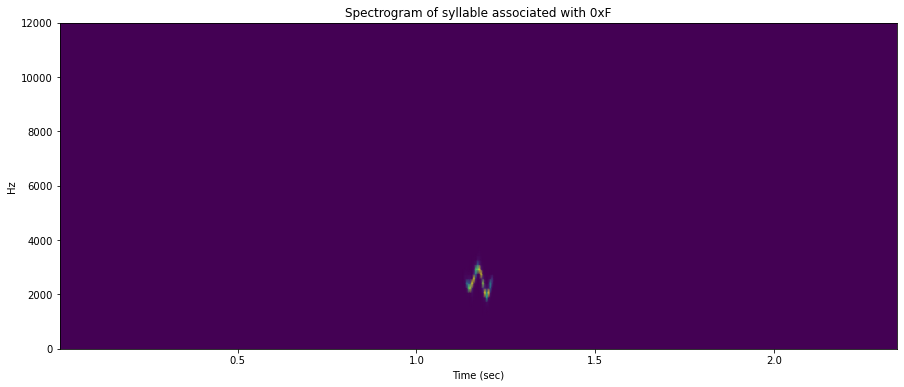

In [16]:
ff, tf, Sxxf = signal.spectrogram(numpy.concatenate((numpy.zeros(50000), hex_f, numpy.zeros(50000))), 44100)
plt.figure(figsize=(15, 6))
plt.pcolormesh(tf, ff, Sxxf,  shading='gouraud')
plt.ylabel('Hz'); plt.xlabel('Time (sec)')
plt.title('Spectrogram of syllable associated with 0xF')
plt.ylim([0,12000])
plt.show()

And here is what it sounds like:

In [17]:
Audio(hex_f, rate=44100)

The spectrogram below shows all of our synthesized syllables, and their associated symbols:

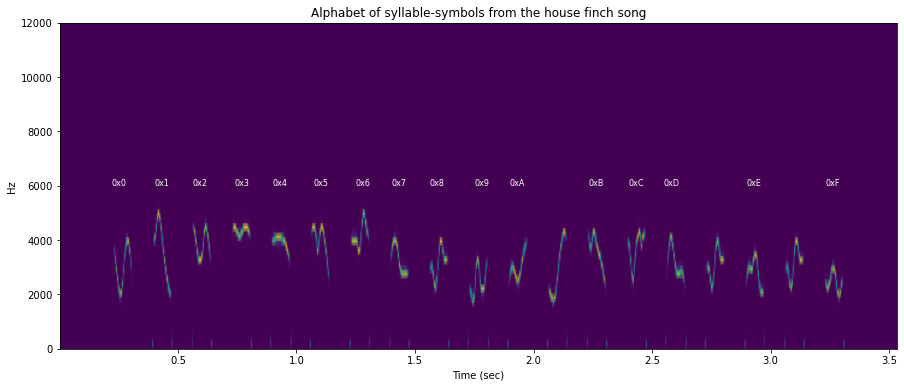

In [11]:
f, t, Sxx = signal.spectrogram(simulated_song, 44100)
plt.figure(figsize=(15, 6))
plt.pcolormesh(t, f, Sxx,  shading='gouraud')
plt.ylabel('Hz'); plt.xlabel('Time (sec)')
plt.title('Alphabet of syllable-symbols from the house finch song')
plt.ylim([0,12000])

plt.text(0.22, 6000, '0x0', fontsize=8, color='white')
plt.text(0.4, 6000, '0x1', fontsize=8, color='white')
plt.text(0.56, 6000, '0x2', fontsize=8, color='white')
plt.text(0.74, 6000, '0x3', fontsize=8, color='white')
plt.text(0.90, 6000, '0x4', fontsize=8, color='white')
plt.text(1.07, 6000, '0x5', fontsize=8, color='white')

plt.text(1.25, 6000, '0x6', fontsize=8, color='white')
plt.text(1.40, 6000, '0x7', fontsize=8, color='white')
plt.text(1.56, 6000, '0x8', fontsize=8, color='white')
plt.text(1.75, 6000, '0x9', fontsize=8, color='white')
plt.text(1.90, 6000, '0xA', fontsize=8, color='white')

plt.text(2.23, 6000, '0xB', fontsize=8, color='white')
plt.text(2.40, 6000, '0xC', fontsize=8, color='white')
plt.text(2.55, 6000, '0xD', fontsize=8, color='white')
plt.text(2.90, 6000, '0xE', fontsize=8, color='white')
plt.text(3.23, 6000, '0xF', fontsize=8, color='white')


plt.show()

### Composing songs

By stringing together these syllables, we can make songs!

#### The real song

It makes sense to start by emulating the real birdsong, to see how convincing our synthesizer is. You can listen to this song below. Maybe *really* careful listeners will be able to distinguish the synthetic from the natural, but it would sure trick me!

In [20]:
simulated_song = np.concatenate((numpy.zeros(10000),
                      hex_0,
                      numpy.zeros(3674),
                      hex_1,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_3,
                      numpy.zeros(3674),
                      hex_4,
                      numpy.zeros(3674),
                      hex_5,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_8,
                      numpy.zeros(3674),
                      hex_9,
                      numpy.zeros(3674),
                      hex_a,
                      numpy.zeros(3674),
                      gap_syl,
                      numpy.zeros(3674),
                      hex_b,
                      numpy.zeros(3674),
                      hex_c,
                      numpy.zeros(3674),
                      hex_d,
                      numpy.zeros(3674),
                      hex_8,
                      numpy.zeros(3674),
                      hex_e,
                      numpy.zeros(3674),
                      hex_8,
                      numpy.zeros(3674),
                      hex_f,
                      numpy.zeros(10000)))

Here is what the synthesized song sounds like:

In [21]:
Audio(simulated_song, rate=44100)

Merlin, the app from Cornell's Lab of Ornithology, provides a nice mechanism for comparing our synthesizer to the real bird. You can see the real bird song on the left, and the synthesized birdsong on the right. In addition to sounding correct to human (or, at least, to my own) ears, the synthesizer is good enough to trick the app into thinking it hears a house finch.

<table>
  <caption> Real (left) vs. synthesized (right) house finch song </caption>
  <tr>
    <td><img src="real.PNG" width="200"></td>
    <td><img src="synthesized_real.PNG" width="200"></td>
  </tr>
</table>

In [22]:
wavfile.write('Simulated.wav', 44100, simulated_song)

#### Hello world!

With our syllable synthesizer, we can compose messages! We'll start with "Hello world!" We compose this song by considering each character in the message that we'd like to send. For each character, we lookup its associated ASCII value. This is a two-byte number representable with two hex values. For instance, the ASCII value for "H" is 0x48. We send an "H" by first synthesizing the finch syllable associated with 0x4, and then the syllable associated with 0x8. Repeat for each character in the message to compose our steganographic song.

The result, as you can see in the annotated spectrogram below, is a synthetic finch song composed of a non-natural arrangement of syllables. But if you listen to it, it still sounds quite natural to the ear! Indeed, it still tricks Merlin.

In [351]:
hello_world = np.concatenate((numpy.zeros(10000),
                      hex_4,
                      numpy.zeros(3674),
                      hex_8,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_5,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_c,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_c,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_f,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_0,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_f,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_c,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_4,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_1,
                      numpy.zeros(10000)))

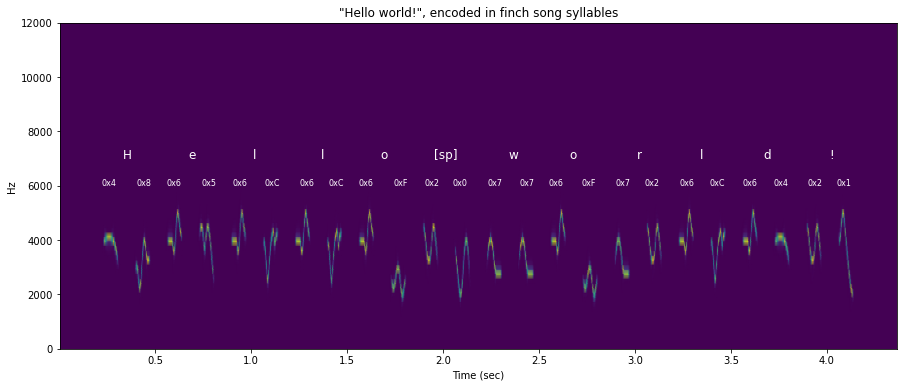

In [352]:
f, t, Sxx = signal.spectrogram(hello_world, 44100)
plt.figure(figsize=(15, 6))
plt.pcolormesh(t, f, Sxx,  shading='gouraud')
plt.ylabel('Hz'); plt.xlabel('Time (sec)')
plt.title('\"Hello world!\", encoded in finch song syllables')
plt.ylim([0,12000])

plt.text(0.22, 6000, '0x4', fontsize=8, color='white')
plt.text(0.4, 6000, '0x8', fontsize=8, color='white')
plt.text(0.33, 7000, 'H', fontsize=12, color='white')

plt.text(0.56, 6000, '0x6', fontsize=8, color='white')
plt.text(0.74, 6000, '0x5', fontsize=8, color='white')
plt.text(0.67, 7000, 'e', fontsize=12, color='white')

plt.text(0.90, 6000, '0x6', fontsize=8, color='white')
plt.text(1.07, 6000, '0xC', fontsize=8, color='white')
plt.text(1.01, 7000, 'l', fontsize=12, color='white')

plt.text(1.25, 6000, '0x6', fontsize=8, color='white')
plt.text(1.40, 6000, '0xC', fontsize=8, color='white')
plt.text(1.36, 7000, 'l', fontsize=12, color='white')

plt.text(1.56, 6000, '0x6', fontsize=8, color='white')
plt.text(1.74, 6000, '0xF', fontsize=8, color='white')
plt.text(1.67, 7000, 'o', fontsize=12, color='white')

plt.text(1.90, 6000, '0x2', fontsize=8, color='white')
plt.text(2.05, 6000, '0x0', fontsize=8, color='white')
plt.text(1.95, 7000, '[sp]', fontsize=12, color='white')

plt.text(2.23, 6000, '0x7', fontsize=8, color='white')
plt.text(2.40, 6000, '0x7', fontsize=8, color='white')
plt.text(2.34, 7000, 'w', fontsize=12, color='white')

plt.text(2.55, 6000, '0x6', fontsize=8, color='white')
plt.text(2.72, 6000, '0xF', fontsize=8, color='white')
plt.text(2.66, 7000, 'o', fontsize=12, color='white')

plt.text(2.90, 6000, '0x7', fontsize=8, color='white')
plt.text(3.05, 6000, '0x2', fontsize=8, color='white')
plt.text(3.01, 7000, 'r', fontsize=12, color='white')

plt.text(3.23, 6000, '0x6', fontsize=8, color='white')
plt.text(3.39, 6000, '0xC', fontsize=8, color='white')
plt.text(3.34, 7000, 'l', fontsize=12, color='white')

plt.text(3.56, 6000, '0x6', fontsize=8, color='white')
plt.text(3.72, 6000, '0x4', fontsize=8, color='white')
plt.text(3.67, 7000, 'd', fontsize=12, color='white')

plt.text(3.90, 6000, '0x2', fontsize=8, color='white')
plt.text(4.05, 6000, '0x1', fontsize=8, color='white')
plt.text(4.01, 7000, '!', fontsize=12, color='white')


plt.show()

Here's what "Hello world!" sounds like:

In [354]:
Audio(hello_world, rate=44100)

In [355]:
wavfile.write('Helloworld.wav', 44100, hello_world)

And it still tricks Merlin!

<img src="helloworld.PNG" width="300">

#### Birds aren't real

Because this strikes me as potentially hilarious fodder for one of my [favorite conspiracies](https://en.wikipedia.org/wiki/Birds_Aren%27t_Real), here is the message "Birds aren't real."

In [356]:
unreal = np.concatenate((numpy.zeros(10000),
                      hex_4,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_9,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_4,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_3,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_0,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_1,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_5,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_e,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_4,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_0,
                      numpy.zeros(3674),
                      hex_7,
                      numpy.zeros(3674),
                      hex_2,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_5,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_1,
                      numpy.zeros(3674),
                      hex_6,
                      numpy.zeros(3674),
                      hex_c,
                      numpy.zeros(10000)))

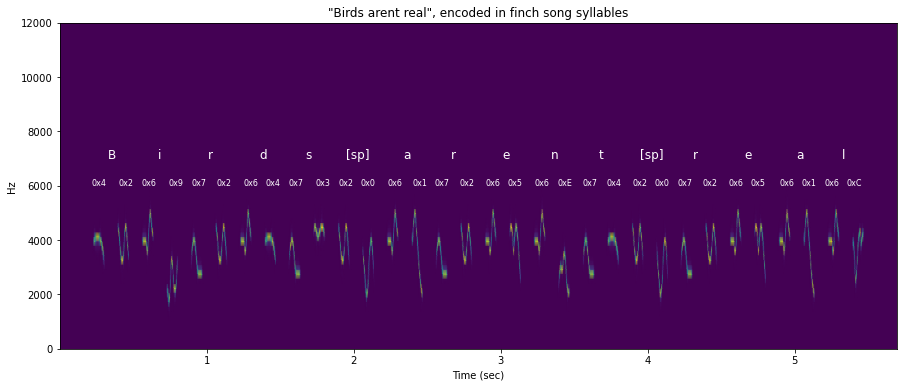

In [366]:
f, t, Sxx = signal.spectrogram(unreal, 44100)
plt.figure(figsize=(15, 6))
plt.pcolormesh(t, f, Sxx,  shading='gouraud')
plt.ylabel('Hz'); plt.xlabel('Time (sec)')
plt.title('\"Birds arent real\", encoded in finch song syllables')
plt.ylim([0,12000])

plt.text(0.22, 6000, '0x4', fontsize=8, color='white')
plt.text(0.4, 6000, '0x2', fontsize=8, color='white')
plt.text(0.33, 7000, 'B', fontsize=12, color='white')

plt.text(0.56, 6000, '0x6', fontsize=8, color='white')
plt.text(0.74, 6000, '0x9', fontsize=8, color='white')
plt.text(0.67, 7000, 'i', fontsize=12, color='white')

plt.text(0.90, 6000, '0x7', fontsize=8, color='white')
plt.text(1.07, 6000, '0x2', fontsize=8, color='white')
plt.text(1.01, 7000, 'r', fontsize=12, color='white')

plt.text(1.25, 6000, '0x6', fontsize=8, color='white')
plt.text(1.40, 6000, '0x4', fontsize=8, color='white')
plt.text(1.36, 7000, 'd', fontsize=12, color='white')

plt.text(1.56, 6000, '0x7', fontsize=8, color='white')
plt.text(1.74, 6000, '0x3', fontsize=8, color='white')
plt.text(1.67, 7000, 's', fontsize=12, color='white')

plt.text(1.90, 6000, '0x2', fontsize=8, color='white')
plt.text(2.05, 6000, '0x0', fontsize=8, color='white')
plt.text(1.95, 7000, '[sp]', fontsize=12, color='white')

plt.text(2.23, 6000, '0x6', fontsize=8, color='white')
plt.text(2.40, 6000, '0x1', fontsize=8, color='white')
plt.text(2.34, 7000, 'a', fontsize=12, color='white')

plt.text(2.55, 6000, '0x7', fontsize=8, color='white')
plt.text(2.72, 6000, '0x2', fontsize=8, color='white')
plt.text(2.66, 7000, 'r', fontsize=12, color='white')

plt.text(2.90, 6000, '0x6', fontsize=8, color='white')
plt.text(3.05, 6000, '0x5', fontsize=8, color='white')
plt.text(3.01, 7000, 'e', fontsize=12, color='white')

plt.text(3.23, 6000, '0x6', fontsize=8, color='white')
plt.text(3.39, 6000, '0xE', fontsize=8, color='white')
plt.text(3.34, 7000, 'n', fontsize=12, color='white')

plt.text(3.56, 6000, '0x7', fontsize=8, color='white')
plt.text(3.72, 6000, '0x4', fontsize=8, color='white')
plt.text(3.67, 7000, 't', fontsize=12, color='white')

plt.text(3.90, 6000, '0x2', fontsize=8, color='white')
plt.text(4.05, 6000, '0x0', fontsize=8, color='white')
plt.text(3.95, 7000, '[sp]', fontsize=12, color='white')


plt.text(4.20, 6000, '0x7', fontsize=8, color='white')
plt.text(4.37, 6000, '0x2', fontsize=8, color='white')
plt.text(4.31, 7000, 'r', fontsize=12, color='white')

plt.text(4.55, 6000, '0x6', fontsize=8, color='white')
plt.text(4.70, 6000, '0x5', fontsize=8, color='white')
plt.text(4.66, 7000, 'e', fontsize=12, color='white')

plt.text(4.90, 6000, '0x6', fontsize=8, color='white')
plt.text(5.05, 6000, '0x1', fontsize=8, color='white')
plt.text(5.01, 7000, 'a', fontsize=12, color='white')

plt.text(5.20, 6000, '0x6', fontsize=8, color='white')
plt.text(5.35, 6000, '0xC', fontsize=8, color='white')
plt.text(5.32, 7000, 'l', fontsize=12, color='white')

plt.show()

Here is what this song sounds like:

In [367]:
Audio(unreal, rate=44100)

This too tricks Merlin.

<img src="birdsarentreal.PNG" width="300">

In [368]:
wavfile.write('Birdsarentreal.wav', 44100, unreal)

***